In [1]:
import os
import matplotlib.pyplot as plt
from DescriptionLookup import DescriptionLookup

from contexts import Plasmid
from contexts import GenomeRegion
from contexts import make_mcs_insert_fn


from CAGI5_bench import CAGI5_bench

os.environ['GENALM_HOME'] = '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark'
os.environ['PYTHONPATH'] += '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction'

/home/jovyan/miniconda3/envs/cagi5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#REAL
lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])

In [7]:
#GENERATED
lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/descriptions', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])

In [3]:
plasmid = Plasmid('https://www.ncbi.nlm.nih.gov/nuccore/MK484103.1', 
                    data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', 
                    reporter_feature_name='similar to firefly luciferase; synthetic luc2 version of the luciferase gene')

plasmid_context = plasmid.plasmid_context(insert_fn=make_mcs_insert_fn('CCCGGGCTCGAGATC', 'CCGGATTGCCAAGCT'), context_size=10_000, circular=True, allow_repeats=False)

In [ ]:
genome = GenomeRegion(genome_path='/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa')

genome_context = genome.genomic_context(region='AAVS1', target_length=10_000)

In [4]:
plasmid.features

{'source': (1, 4372),
 'Altered MCS': (1, 72),
 'similar to firefly luciferase; synthetic luc2 version of the luciferase gene': (102,
  1751),
 'similar to PEST degradation sequence from mouse ornithine decarboxylase; human codon-optimized': (1755,
  1877),
 'high GC stretch': (1895, 1910),
 'SV40 late poly (A) region': (1917, 2108),
 'rep_origin': (2448, 3130),
 'beta-lactamase': (3254, 4114),
 'synthetic; transcriptional pause site': (4219, 4372)}

In [7]:
plasmid.sequence[102:150]

'TGGAAGATGCCAAAAACATTAAGAAGGGCCCAGCGCCATTCTACCCAC'

In [15]:
plasmid_context('R').find('TGGAAGATGCCAAAAACATTAAGAAGGGCCCAGCGCCATTCTACCCAC')

90

In [8]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=10,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup)

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'],
                            mode='custom', context_fn=genome_context)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:103: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

In [33]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'],
                            mode='custom',
                            cell_type=['HepG2', 'HeLa', 'K562'],
                            context_fn=genome_context)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:103: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

In [9]:
bench.initialize_dataset(elements=['LDLR'], cell_type=['HepG2', 'HeLa', 'K562'],
                            mode='custom', context_fn=genome_context)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:103: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

In [10]:
bench.initialize_dataset(elements=['LDLR'], cell_type=['HepG2', 'HeLa', 'K562'],
                            mode='custom', context_fn=plasmid_context)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:103: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

In [14]:
bench.initialize_dataset(elements=['LDLR', 'F9'], cell_type=['HepG2'],
                            mode='custom', context_fn=plasmid_context)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/CAGI5_bench.py:103: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from /workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/modernbert_large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_pr

In [ ]:
bench.run_inference()

  0%|          | 0/8778 [00:00<?, ?it/s]

In [14]:
bench.corr

{'F9': tensor([[1.0000, 0.1149],
         [0.1149, 1.0000]], device='cuda:6', dtype=torch.float16),
 'FOXE1': tensor([[ 0.9995, -0.0125],
         [-0.0125,  1.0000]], device='cuda:6', dtype=torch.float16),
 'GP1BA': tensor([[ 1.0000, -0.1214],
         [-0.1213,  0.9995]], device='cuda:6', dtype=torch.float16),
 'HBB': tensor([[ 1.0000, -0.0534],
         [-0.0534,  1.0000]], device='cuda:6', dtype=torch.float16),
 'HBG1': tensor([[ 1.0000, -0.0539],
         [-0.0539,  1.0000]], device='cuda:6', dtype=torch.float16),
 'HNF4A': tensor([[1.0000, 0.0456],
         [0.0456, 1.0000]], device='cuda:6', dtype=torch.float16),
 'LDLR': tensor([[0.9995, 0.2676],
         [0.2673, 1.0000]], device='cuda:6', dtype=torch.float16),
 'LDLR.2': tensor([[1.0000, 0.2786],
         [0.2786, 0.9995]], device='cuda:6', dtype=torch.float16),
 'MSMB': tensor([[ 1.0000, -0.0015],
         [-0.0015,  1.0000]], device='cuda:6', dtype=torch.float16),
 'PKLR-24h': tensor([[1.0000, 0.1454],
         [0.1454, 0.9

In [26]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_correlations(corr_dict, figsize=(10, 4), sort=False, ax=None):
    """
    Plot off-diagonal correlation value for each 2x2 tensor in corr_dict.

    corr_dict: dict[str, torch.Tensor]
        Example: {"F9": tensor([[1, r], [r, 1]], device="cuda")}
    """

    rows = []

    for name, mat in corr_dict.items():
        mat = mat.detach().float().cpu()

        if mat.shape != (2, 2):
            raise ValueError(f"{name} has shape {mat.shape}, expected (2, 2)")

        # Average both off-diagonal values in case fp16 makes them slightly different
        corr = ((mat[0, 1] + mat[1, 0]) / 2).item()
        rows.append({"name": name, "correlation": corr})

    df = pd.DataFrame(rows).sort_values(by='correlation', ascending=False)

    if sort:
        df = df.sort_values("correlation")

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=df,
        x="name",
        y="correlation",
        ax=ax,
        color="steelblue",
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("")
    ax.set_ylabel("Correlation")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_ylim(
        min(-0.05, df["correlation"].min() - 0.05),
        max(0.05, df["correlation"].max() + 0.05),
    )

    plt.tight_layout()
    plt.title('Correlation by element | human safe harbor | all cell types')
    return ax, df

/tmp/ipykernel_2901925/3530143327.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


(<Axes: title={'center': 'Correlation by element | human safe harbor | all cell types'}, ylabel='Correlation'>,
         name  correlation
 7     LDLR.2     0.278564
 6       LDLR     0.267456
 9   PKLR-24h     0.145386
 13  TERT-GSc     0.131653
 10  PKLR-48h     0.126343
 0         F9     0.114868
 11  TERT-GAa     0.093506
 12  TERT-GBM     0.082916
 5      HNF4A     0.045593
 14  TERT-HEK     0.036377
 8       MSMB    -0.001512
 1      FOXE1    -0.012501
 3        HBB    -0.053375
 4       HBG1    -0.053864
 2      GP1BA    -0.121368)

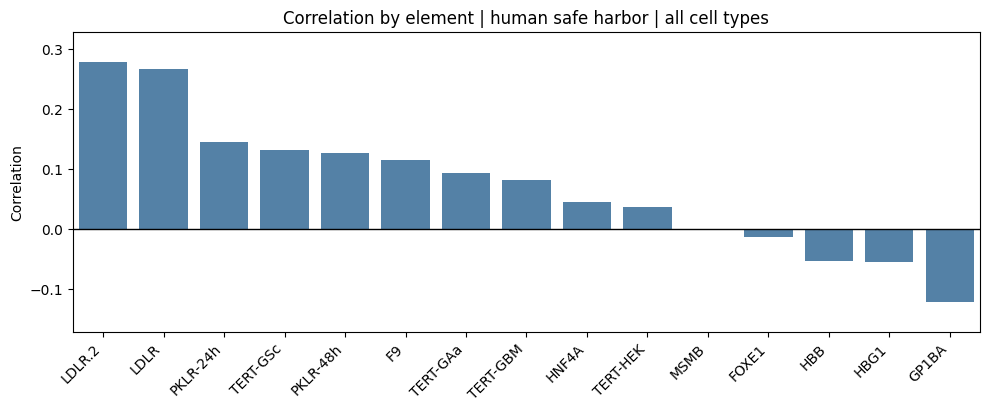

In [27]:
plot_correlations(bench.corr)

In [17]:
bench.true_vs_pred

{'F9': tensor([[-0.2800,  5.3594],
         [ 0.0500,  0.1875],
         [-1.0700,  5.4219],
         ...,
         [ 0.1200,  0.0547],
         [-0.0800, -0.2461],
         [ 0.0100, -0.2773]], device='cuda:6'),
 'LDLR': tensor([[ 0.1400,  0.1406],
         [-0.1300,  0.7344],
         [ 0.0000,  1.7344],
         ...,
         [-0.0400, -0.2812],
         [-0.0400, -0.0938],
         [-0.0600, -0.1406]], device='cuda:6')}

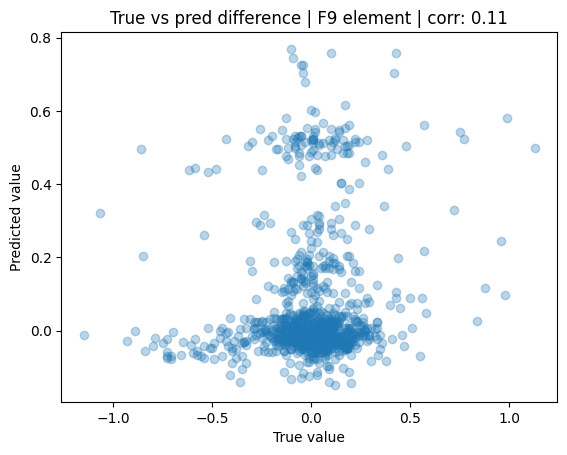

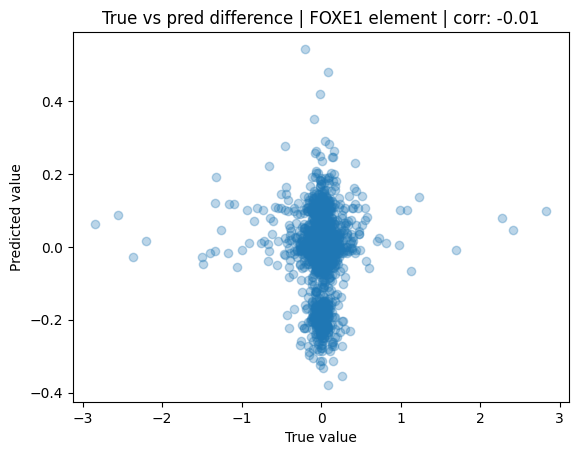

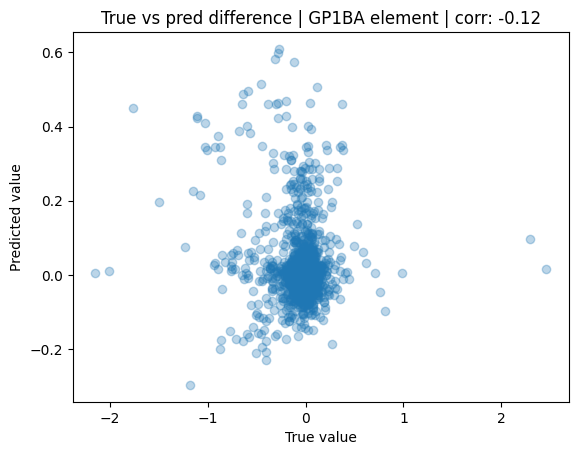

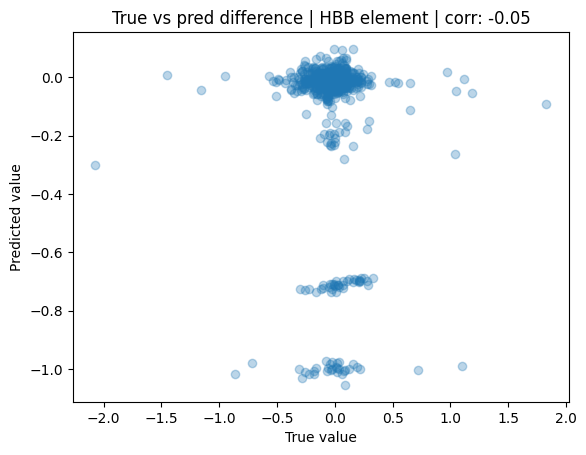

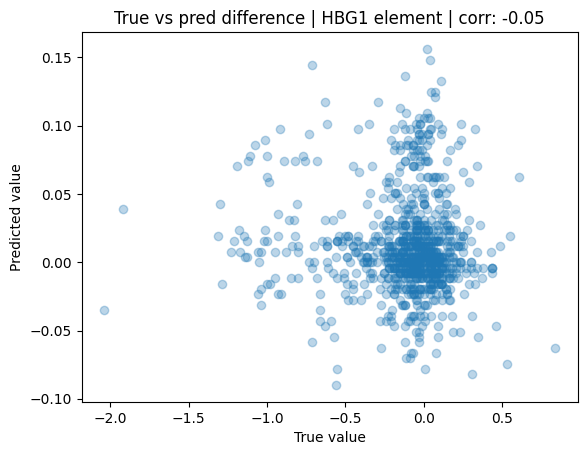

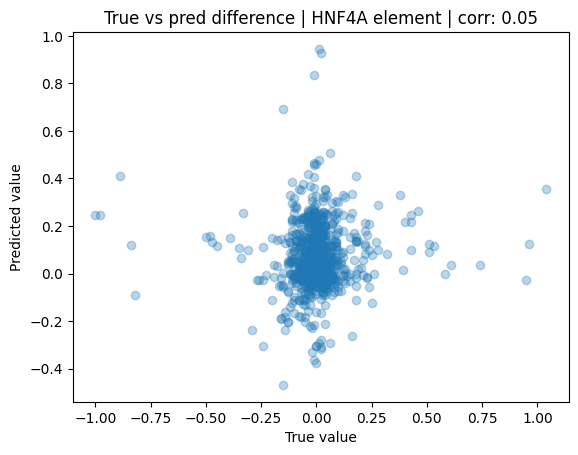

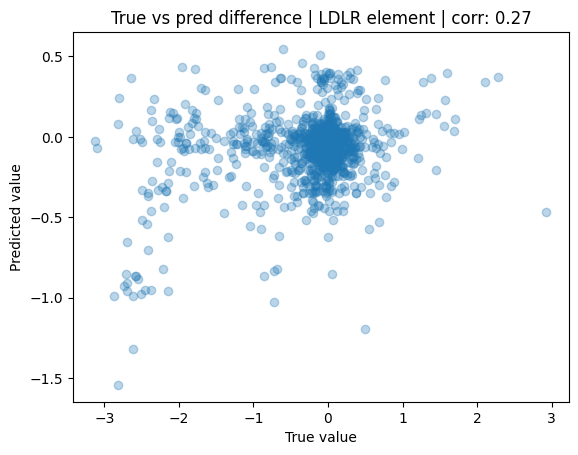

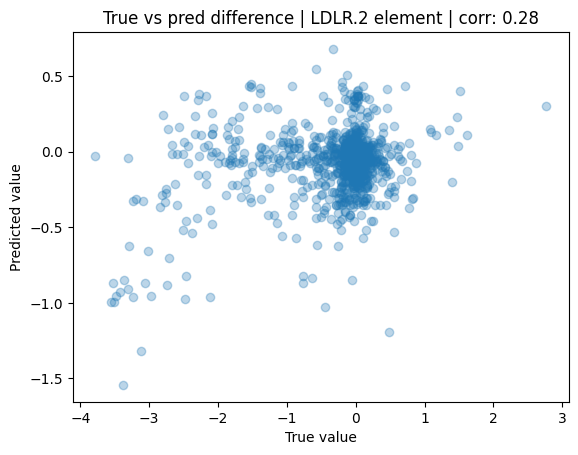

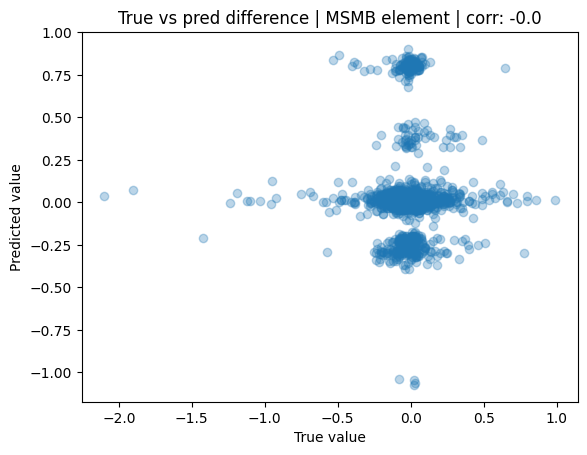

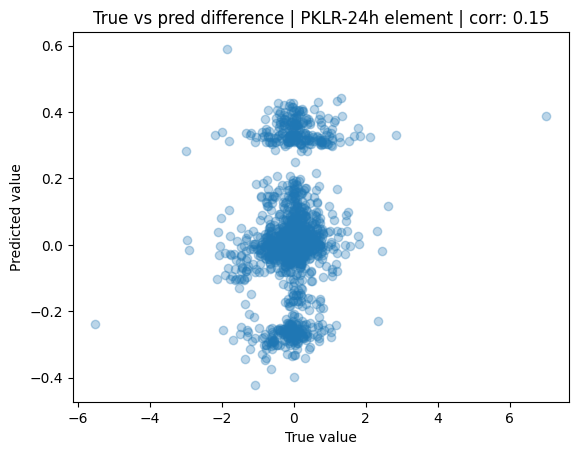

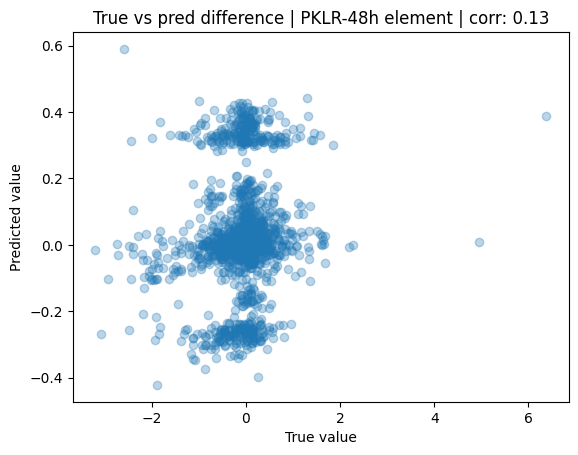

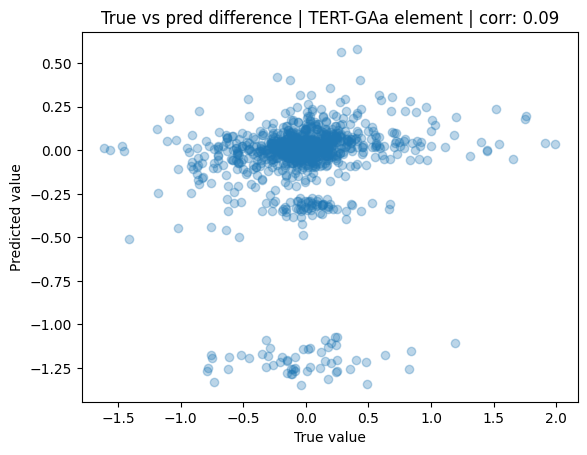

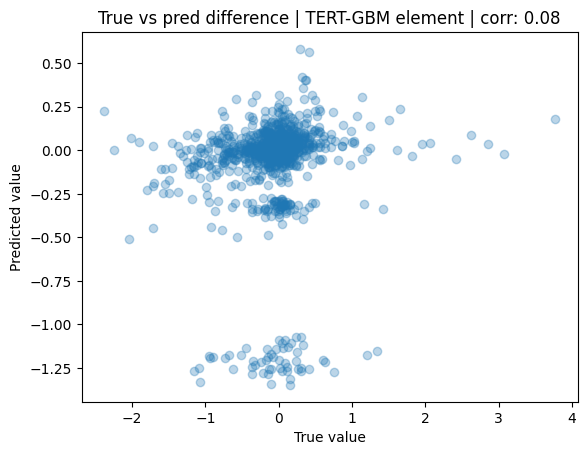

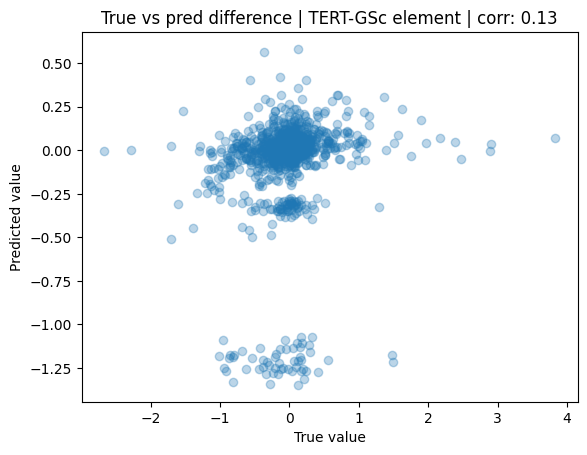

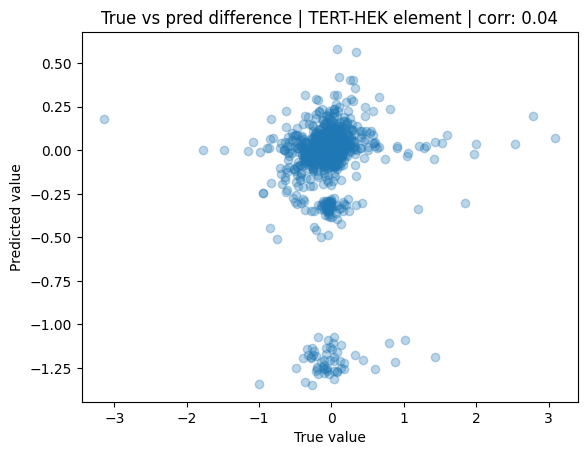

In [ ]:
for key in bench.corr:
    corr = bench.corr[key][0][1].item()
    plt.scatter(x=bench.true_vs_pred[key][:, 0].cpu(), y = bench.true_vs_pred[key][:, 1].cpu(), alpha=0.3)
    plt.xlabel('True value')
    plt.ylabel('Predicted value')
    plt.title(f'True vs pred difference | {key} element | corr: {round(corr, 2)}')
    plt.show()
    plt.close()

In [ ]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=10,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup)



In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'],
                            mode='custom', context_fn=plasmid_context)
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()